In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split

print("Alle Pakete geladen ✓")

C:\Users\megab\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Alle Pakete geladen ✓


In [2]:
np.random.seed(42)
n = 1000

druck = np.random.normal(150, 20, n)
temperatur = np.random.normal(75, 10, n)
durchfluss = np.random.normal(50, 8, n)
vibration = np.random.normal(0.5, 0.1, n)
betriebsstunden = np.random.uniform(0, 10000, n)

ausfall = (
    0.3 * (temperatur / 100) +
    0.4 * (vibration / 1.0) +
    0.2 * (betriebsstunden / 10000) +
    0.1 * (druck / 200) +
    np.random.normal(0, 0.05, n)
).clip(0, 1)

df = pd.DataFrame({
    'Druck': druck,
    'Temperatur': temperatur,
    'Durchfluss': durchfluss,
    'Vibration': vibration,
    'Betriebsstunden': betriebsstunden,
    'Ausfall': ausfall
})

X = df.drop('Ausfall', axis=1)
y = df['Ausfall']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bestes Modell laden
model = joblib.load('model_lgb_v1.pkl')
print("Daten und Modell geladen ✓")

Daten und Modell geladen ✓


In [3]:
# SHAP Explainer erstellen
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP Werte berechnet ✓")
print(f"Form: {shap_values.shape}")

SHAP Werte berechnet ✓
Form: (200, 5)


C:\Users\megab\AppData\Local\Temp\ipykernel_3600\634363147.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=True)


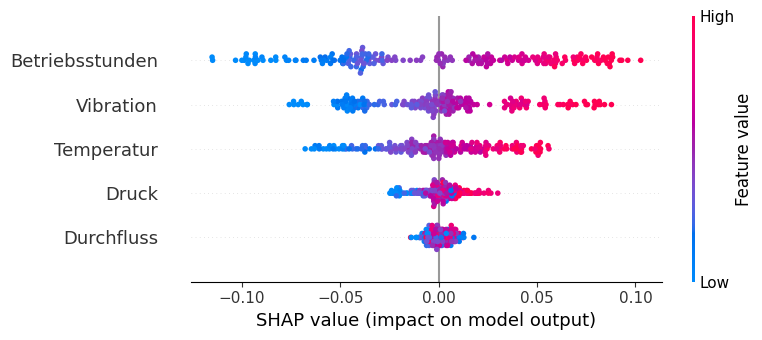

<Figure size 640x480 with 0 Axes>

In [4]:
shap.summary_plot(shap_values, X_test, show=True)
plt.tight_layout()

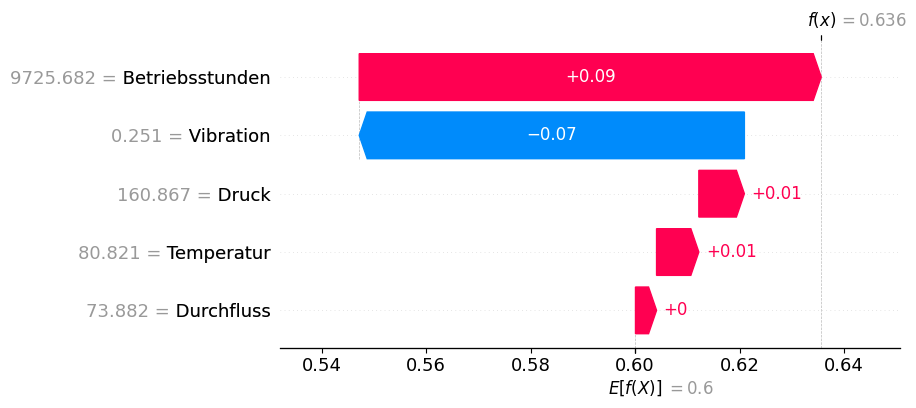

In [5]:
# Waterfall Plot — Maschine Nummer 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns.tolist()
    )
)

In [6]:
import os
os.makedirs('figures', exist_ok=True)

# Summary Plot speichern
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()

# Waterfall Plot speichern
fig, ax = plt.subplots()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.savefig('figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.close()

print("Beide Plots gespeichert ✓")

C:\Users\megab\AppData\Local\Temp\ipykernel_3600\3970858604.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


Beide Plots gespeichert ✓


Ausfallwahrscheinlichkeit: 77.8%


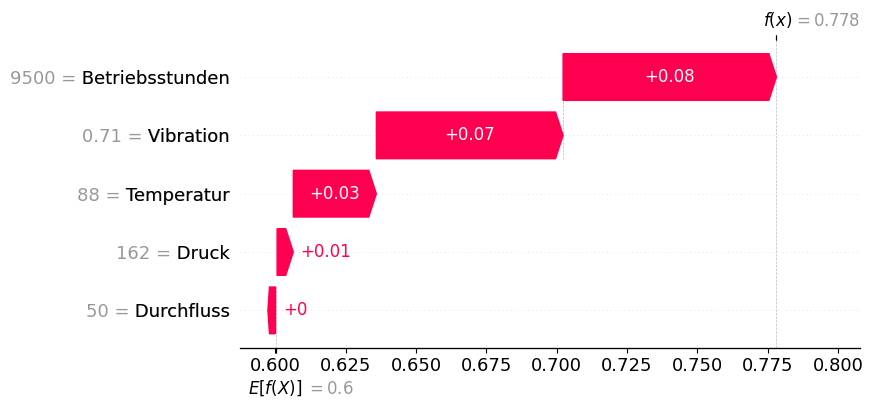

In [7]:
# Eine sehr kranke Maschine erstellen
kranke_maschine = pd.DataFrame({
    'Druck': [162],
    'Temperatur': [88],
    'Durchfluss': [50],
    'Vibration': [0.71],
    'Betriebsstunden': [9500]
})

# Vorhersage
vorhersage = model.predict(kranke_maschine)[0]
print(f"Ausfallwahrscheinlichkeit: {vorhersage:.1%}")

# SHAP Werte berechnen
shap_krank = explainer.shap_values(kranke_maschine)

# Waterfall Plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_krank[0],
        base_values=explainer.expected_value,
        data=kranke_maschine.iloc[0],
        feature_names=kranke_maschine.columns.tolist()
    )
)

Ausfallwahrscheinlichkeit: 45.7%


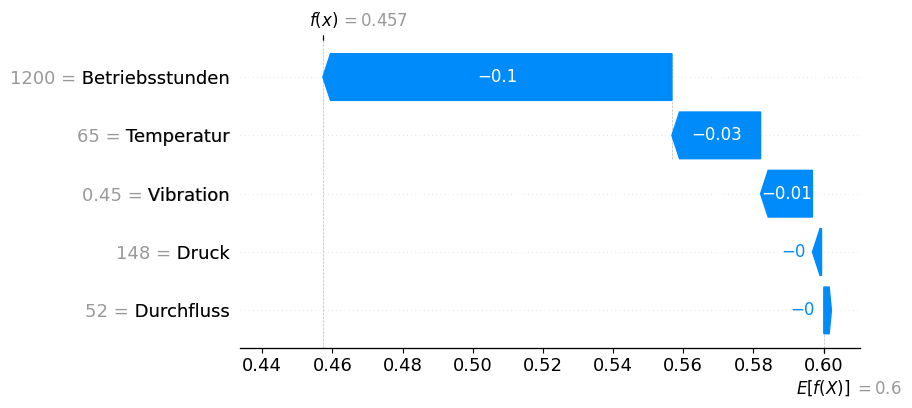

In [8]:
# Gesunde Maschine
gesunde_maschine = pd.DataFrame({
    'Druck': [148],
    'Temperatur': [65],
    'Durchfluss': [52],
    'Vibration': [0.45],
    'Betriebsstunden': [1200]
})

vorhersage_g = model.predict(gesunde_maschine)[0]
print(f"Ausfallwahrscheinlichkeit: {vorhersage_g:.1%}")

shap_gesund = explainer.shap_values(gesunde_maschine)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_gesund[0],
        base_values=explainer.expected_value,
        data=gesunde_maschine.iloc[0],
        feature_names=gesunde_maschine.columns.tolist()
    )
)

In [9]:
import os
os.makedirs('figures', exist_ok=True)

# Kranke Maschine speichern
shap.plots.waterfall(
    shap.Explanation(
        values=shap_krank[0],
        base_values=explainer.expected_value,
        data=kranke_maschine.iloc[0],
        feature_names=kranke_maschine.columns.tolist()
    ), show=False
)
plt.savefig('figures/shap_waterfall_krank.png', dpi=150, bbox_inches='tight')
plt.close()

# Gesunde Maschine speichern
shap.plots.waterfall(
    shap.Explanation(
        values=shap_gesund[0],
        base_values=explainer.expected_value,
        data=gesunde_maschine.iloc[0],
        feature_names=gesunde_maschine.columns.tolist()
    ), show=False
)
plt.savefig('figures/shap_waterfall_gesund.png', dpi=150, bbox_inches='tight')
plt.close()

print("Beide Plots gespeichert ✓")

Beide Plots gespeichert ✓
